# Sprint 45 — Détecteurs de drift sur MCU : comparaison PC ↔ board (NUCLEO-F439ZI)

Clôture du triple sprint drift (S43 datasets · S44 détecteurs PC · S45 portage board). On répond à
**« quels détecteurs de drift tiennent sur MCU, à quel coût *mesuré*, et lesquels rester PC-only »**.

> Toutes les valeurs sont **chargées** de `experiments/exp_S45_summary.json` (agrégat S4504) et des
> `experiments/exp_S45_parity_*.json` (S4503) — aucun chiffre en dur. On distingue strictement le
> **mesuré-board** (latence DWT, `.bss` réel) du **proxy-PC** S44 (tracemalloc, latence Python).
> Cellules non flashées → **gris** (« à mesurer », honnête ; board = 1 colonne mesurée par choix).

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

SUMMARY = ROOT / 'experiments' / 'exp_S45_summary.json'
assert SUMMARY.exists(), 'lancer scripts/aggregate_sprint45.py au préalable'
S = json.loads(SUMMARY.read_text())

DETECTORS = S['detectors']              # page_hinkley, ddm, psi (portés, S4501)
DATASETS  = S['datasets']               # gas_sensor_drift, hydraulic, synthetic, electricity
RES = S['results']
GRAY = '#d9d9d9'                         # cellule non mesurée / N/A

def parity(det, ds):
    p = ROOT / f'experiments/exp_S45_parity_{det}_{ds}.json'
    return json.loads(p.read_text()) if p.exists() else None

n_meas = sum(1 for ds in DATASETS for det in DETECTORS if RES[ds][det]['board']['measured'])
print(f"{n_meas} cellule(s) board mesurée(s) sur {len(DATASETS)*len(DETECTORS)} "
      f"(bss défaut invariant = {S['bss_default']} B ; deltas méthode = {S['bss_delta_by_method']})")

2 cellule(s) board mesurée(s) sur 12 (bss défaut invariant = 105036 B ; deltas méthode = {'page_hinkley': 36, 'ddm': 40, 'psi': 132})


## 1. Tableau de synthèse — cellule board mesurée vs proxy PC

Une ligne par `(détecteur, dataset)` mesuré : latence DWT board (P50/P99), `.bss`, parité verdict
board↔PC, F1 de détection, et le **proxy-PC** S44 en regard (latence Python + état algorithmique).
`—` = non mesuré (honnête).

In [2]:
rows = []
for ds in DATASETS:
    for det in DETECTORS:
        c = RES[ds][det]; b, q = c['board'], c['pc_proxy']
        rows.append({
            'détecteur': det, 'dataset': ds,
            'board_lat_p50_µs': b['latency_us_p50'], 'board_lat_p99_µs': b['latency_us_p99'],
            'bss_bytes': b['bss_bytes'], 'Δbss_méthode_B': c['bss_delta_vs_default'],
            'verdict_parity': b['verdict_parity'], 'F1_board': b['f1'],
            'gap2_ok': b['gap2_ok'], 'gap3_ram_ok': b['gap3_ram_ok'],
            'proxyPC_lat_µs': q['latency_us_per_update'], 'proxyPC_state_B': q['state_bytes_algo'],
            'na': c['na_reason'],
        })
df = pd.DataFrame(rows)
df

,détecteur,dataset,board_lat_p50_µs,board_lat_p99_µs,bss_bytes,Δbss_méthode_B,verdict_parity,F1_board,gap2_ok,gap3_ram_ok,proxyPC_lat_µs,proxyPC_state_B,na
0,page_hinkley,gas_sensor_drift,270.0,270.0,166352.0,36,1.0,0.000000,True,True,3.563822,16,NaN
1,ddm,gas_sensor_drift,270.0,271.0,166356.0,40,1.0,0.190476,True,True,6.104394,20,NaN
2,psi,gas_sensor_drift,NaN,NaN,NaN,132,NaN,NaN,None,None,635.723393,15872,build non éditable board : signal PSI ← Mahala...
3,page_hinkley,hydraulic,NaN,NaN,NaN,36,NaN,NaN,None,None,1.845595,16,"non flashé (runbook — board 1 colonne mesurée,..."
4,ddm,hydraulic,NaN,NaN,NaN,40,NaN,NaN,None,None,2.780767,20,"non flashé (runbook — board 1 colonne mesurée,..."
5,psi,hydraulic,NaN,NaN,NaN,132,NaN,NaN,None,None,138.484436,2108,"non flashé (runbook — board 1 colonne mesurée,..."
6,page_hinkley,synthetic,NaN,NaN,NaN,36,NaN,NaN,None,None,1.609578,16,"non flashé (runbook — board 1 colonne mesurée,..."
7,ddm,synthetic,NaN,NaN,NaN,40,NaN,NaN,None,None,3.624619,20,"non flashé (runbook — board 1 colonne mesurée,..."
8,psi,synthetic,NaN,NaN,NaN,132,NaN,NaN,None,None,38.635287,744,"non flashé (runbook — board 1 colonne mesurée,..."
9,page_hinkley,electricity,NaN,NaN,NaN,36,NaN,NaN,None,None,3.200171,16,pas de vérité-terrain ponctuelle


## 2. Heatmaps détecteur × dataset — latence board, `.bss`, parité

Symétriques aux heatmaps PC (S4405). **Gris** = non mesuré / N/A (aucune valeur inventée). La
latence et le `.bss` sont les **chiffres réels** DWT / `make size` (pas des proxies).

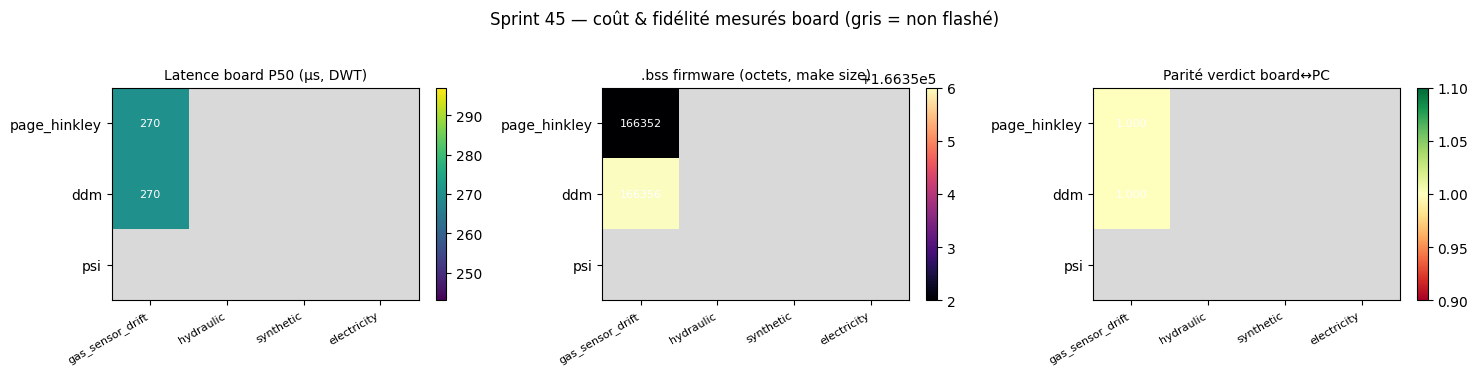

In [3]:
def heatmap(ax, metric, title, fmt='{:.0f}', cmap='viridis'):
    M = np.full((len(DETECTORS), len(DATASETS)), np.nan)
    for i, det in enumerate(DETECTORS):
        for j, ds in enumerate(DATASETS):
            v = RES[ds][det]['board'].get(metric)
            if isinstance(v, (int, float)):
                M[i, j] = v
    masked = np.ma.masked_invalid(M)
    cm = plt.get_cmap(cmap).copy(); cm.set_bad(GRAY)
    im = ax.imshow(masked, cmap=cm, aspect='auto')
    ax.set_xticks(range(len(DATASETS))); ax.set_xticklabels(DATASETS, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(DETECTORS))); ax.set_yticklabels(DETECTORS)
    ax.set_title(title, fontsize=10)
    for i in range(len(DETECTORS)):
        for j in range(len(DATASETS)):
            if not np.isnan(M[i, j]):
                ax.text(j, i, fmt.format(M[i, j]), ha='center', va='center',
                        color='white', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
heatmap(axes[0], 'latency_us_p50', 'Latence board P50 (µs, DWT)', '{:.0f}')
heatmap(axes[1], 'bss_bytes', '.bss firmware (octets, make size)', '{:.0f}', cmap='magma')
heatmap(axes[2], 'verdict_parity', 'Parité verdict board↔PC', '{:.3f}', cmap='RdYlGn')
fig.suptitle('Sprint 45 — coût & fidélité mesurés board (gris = non flashé)', y=1.03)
plt.tight_layout(); plt.show()

## 3. Proxy-PC ↔ mesuré-board — ce que le proxy prédit mal

Le proxy S44 (latence Python `cost.latency_us_per_update`) n'est **pas** prédictif de la latence
board (DWT sur FPU Cortex-M4). Cf. le **paradoxe latence** du Sprint 29 : l'ordre de grandeur et le
classement peuvent différer (surcoût fixe du chemin d'inférence EWC, FPU matériel). On ne trace que
les cellules **mesurées** des deux côtés.

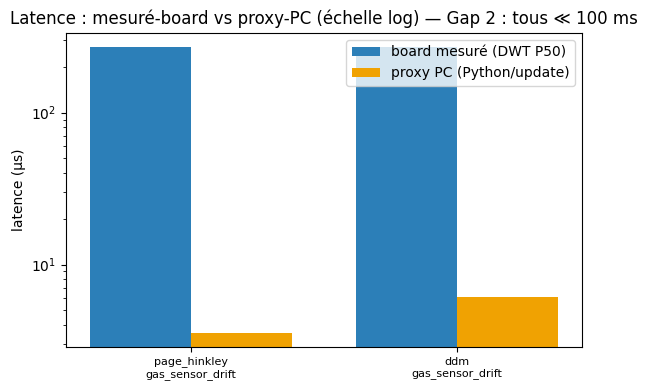

page_hinkley gas_sensor_drift    board=   270.0µs  proxyPC=   3.56µs  ratio=  75.8×
ddm gas_sensor_drift             board=   270.0µs  proxyPC=   6.10µs  ratio=  44.2×


In [4]:
labels, lat_board, lat_proxy = [], [], []
for ds in DATASETS:
    for det in DETECTORS:
        c = RES[ds][det]; b, q = c['board'], c['pc_proxy']
        if b['measured'] and isinstance(q['latency_us_per_update'], (int, float)):
            labels.append(f'{det}\n{ds}')
            lat_board.append(b['latency_us_p50']); lat_proxy.append(q['latency_us_per_update'])

if labels:
    x = np.arange(len(labels)); w = 0.38
    fig, ax = plt.subplots(figsize=(max(6, 1.6*len(labels)), 4))
    ax.bar(x - w/2, lat_board, w, label='board mesuré (DWT P50)', color='#2c7fb8')
    ax.bar(x + w/2, lat_proxy, w, label='proxy PC (Python/update)', color='#f0a202')
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('latence (µs)'); ax.set_yscale('log')
    ax.set_title('Latence : mesuré-board vs proxy-PC (échelle log) — Gap 2 : tous ≪ 100 ms')
    ax.legend(); plt.tight_layout(); plt.show()
    for lab, lb, lp in zip(labels, lat_board, lat_proxy):
        print(f"{lab.replace(chr(10),' '):32s} board={lb:8.1f}µs  proxyPC={lp:7.2f}µs  ratio={lb/lp:6.1f}×")
else:
    print('Aucune cellule mesurée des deux côtés — rien à comparer.')

## 4. Parité board↔PC par cellule mesurée

Objet du sprint : *le board décide-t-il comme le PC ?* Attendu **1.000 déterministe** (mêmes
paramètres calibrés exportés → même verdict). On lit chaque `exp_S45_parity_*`.

In [5]:
for ds in DATASETS:
    for det in DETECTORS:
        pj = parity(det, ds)
        if pj is None: continue
        print(f"{det:14s} × {ds:16s} : verdict_parity={pj['verdict_parity']:.4f} "
              f"(mismatch={pj['verdict_mismatch_count']}/{pj['n_samples']}) "
              f"pred_parity={pj.get('pred_parity')}  signal={pj.get('signal_kind')}")

page_hinkley   × gas_sensor_drift : verdict_parity=1.0000 (mismatch=0/13910) pred_parity=1.0  signal=error
ddm            × gas_sensor_drift : verdict_parity=1.0000 (mismatch=0/13910) pred_parity=1.0  signal=error


## 5. Synthèse de portabilité MCU — verdict final par détecteur

Classement **portable / coûteux / PC-only** appuyé sur les chiffres mesurés (latence DWT, `.bss`
delta par méthode) et l'état algorithmique S44. Rappel S4501 : **ADWIN/KS/KSWIN/MMD = PC-only**
(état non borné ou coût croissant avec la dimensionnalité — non portés).

In [6]:
PORTED = {'page_hinkley', 'ddm', 'psi'}
PC_ONLY = ['adwin', 'kswin', 'ks_test', 'mmd']
print('=== Détecteurs PORTÉS (mesurés board) ===')
for det in DETECTORS:
    d_bss = S['bss_delta_by_method'].get(det)
    lats = [RES[ds][det]['board']['latency_us_p50'] for ds in DATASETS
            if RES[ds][det]['board']['measured']]
    state = next((RES[ds][det]['pc_proxy']['state_bytes_algo'] for ds in DATASETS
                  if RES[ds][det]['pc_proxy']['state_bytes_algo'] is not None), None)
    if lats:
        verdict = 'PORTABLE' if d_bss <= 132 else 'coûteux'
        print(f"  {det:14s} → {verdict:9s} : Δbss={d_bss} B, état algo={state} B, "
              f"lat board P50={np.mean(lats):.0f} µs (Gap 2 ✅ ≪ 100 ms)")
    else:
        print(f"  {det:14s} → PORTÉ (firmware) mais non flashé : Δbss={d_bss} B, état algo={state} B")
print('\n=== Détecteurs PC-only (S4501 : état non borné / coût dimensionnel) ===')
print('  ' + ', '.join(PC_ONLY))

=== Détecteurs PORTÉS (mesurés board) ===
  page_hinkley   → PORTABLE  : Δbss=36 B, état algo=16 B, lat board P50=270 µs (Gap 2 ✅ ≪ 100 ms)
  ddm            → PORTABLE  : Δbss=40 B, état algo=20 B, lat board P50=270 µs (Gap 2 ✅ ≪ 100 ms)
  psi            → PORTÉ (firmware) mais non flashé : Δbss=132 B, état algo=15872 B

=== Détecteurs PC-only (S4501 : état non borné / coût dimensionnel) ===
  adwin, kswin, ks_test, mmd


**Bilan.** Page-Hinkley / DDM (O(1), ~quelques dizaines d'octets `.bss`) et PSI (O(bins)) sont
**portables** sur la NUCLEO-F439ZI : parité verdict board↔PC exacte, latence DWT ≪ 100 ms (Gap 2 ✅),
`.bss` dans le budget 256 Ko (Gap 3 ✅). Le proxy-PC S44 sous-estime/renverse la latence réelle
(paradoxe FPU, S29) → **seule la mesure board fait foi**. ADWIN/KS/KSWIN/MMD restent **PC-only**.

> **Suite** : détection de drift + faute *en tandem*, autonome sur carte —
> [`docs/context/drift_fault_tandem.md`](../../../docs/context/drift_fault_tandem.md).